<a href="https://colab.research.google.com/github/rithya999/Elevate_labs_task7/blob/main/Task7_Sales_Summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Connect to SQLite database (this will create the file)
conn = sqlite3.connect("sales_data.db")

# Create a cursor object to execute SQL commands
cursor = conn.cursor()

print("Database connected successfully!")

Database connected successfully!


In [3]:
# Create sales table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

print("Sales table created successfully!")

Sales table created successfully!


In [4]:
# Clear old data (important if you run multiple times)
cursor.execute("DELETE FROM sales")

# Insert sample sales data
sales_data = [
    ("Pen", 10, 5),
    ("Pencil", 20, 3),
    ("Notebook", 15, 20),
    ("Pen", 5, 5),
    ("Pencil", 10, 3)
]

cursor.executemany("INSERT INTO sales VALUES (?, ?, ?)", sales_data)

# Save changes
conn.commit()

print("Sales data inserted successfully!")

Sales data inserted successfully!


In [5]:
# Check all data inside sales table
check_query = "SELECT * FROM sales"

df_check = pd.read_sql_query(check_query, conn)

print("All Sales Data:")
print(df_check)

All Sales Data:
    product  quantity  price
0       Pen        10    5.0
1    Pencil        20    3.0
2  Notebook        15   20.0
3       Pen         5    5.0
4    Pencil        10    3.0


In [6]:
# Main SQL Summary Query
query = """
SELECT
    product,
    SUM(quantity) AS total_quantity,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

# Execute query and load into pandas
df = pd.read_sql_query(query, conn)

print("Sales Summary:")
print(df)

Sales Summary:
    product  total_quantity  revenue
0  Notebook              15    300.0
1       Pen              15     75.0
2    Pencil              30     90.0


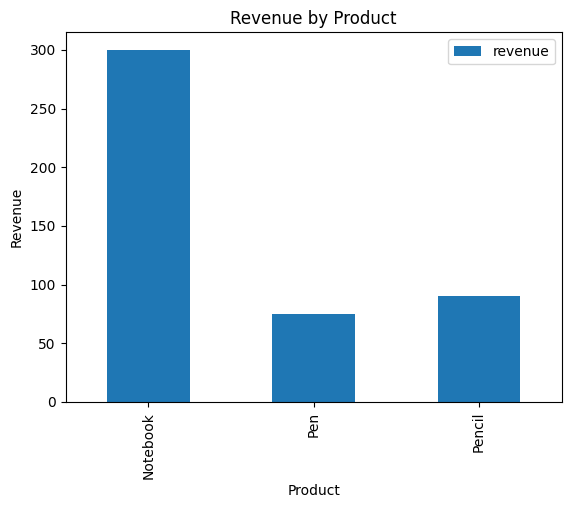

In [7]:
# Plot revenue by product
df.plot(kind='bar', x='product', y='revenue')

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

In [8]:
conn.close()
print("Database connection closed.")

Database connection closed.
